## Упражнение 2.3 (стр.73)

In [24]:
import math
import numpy as np
import matplotlib.pyplot as plt

### Задание 1

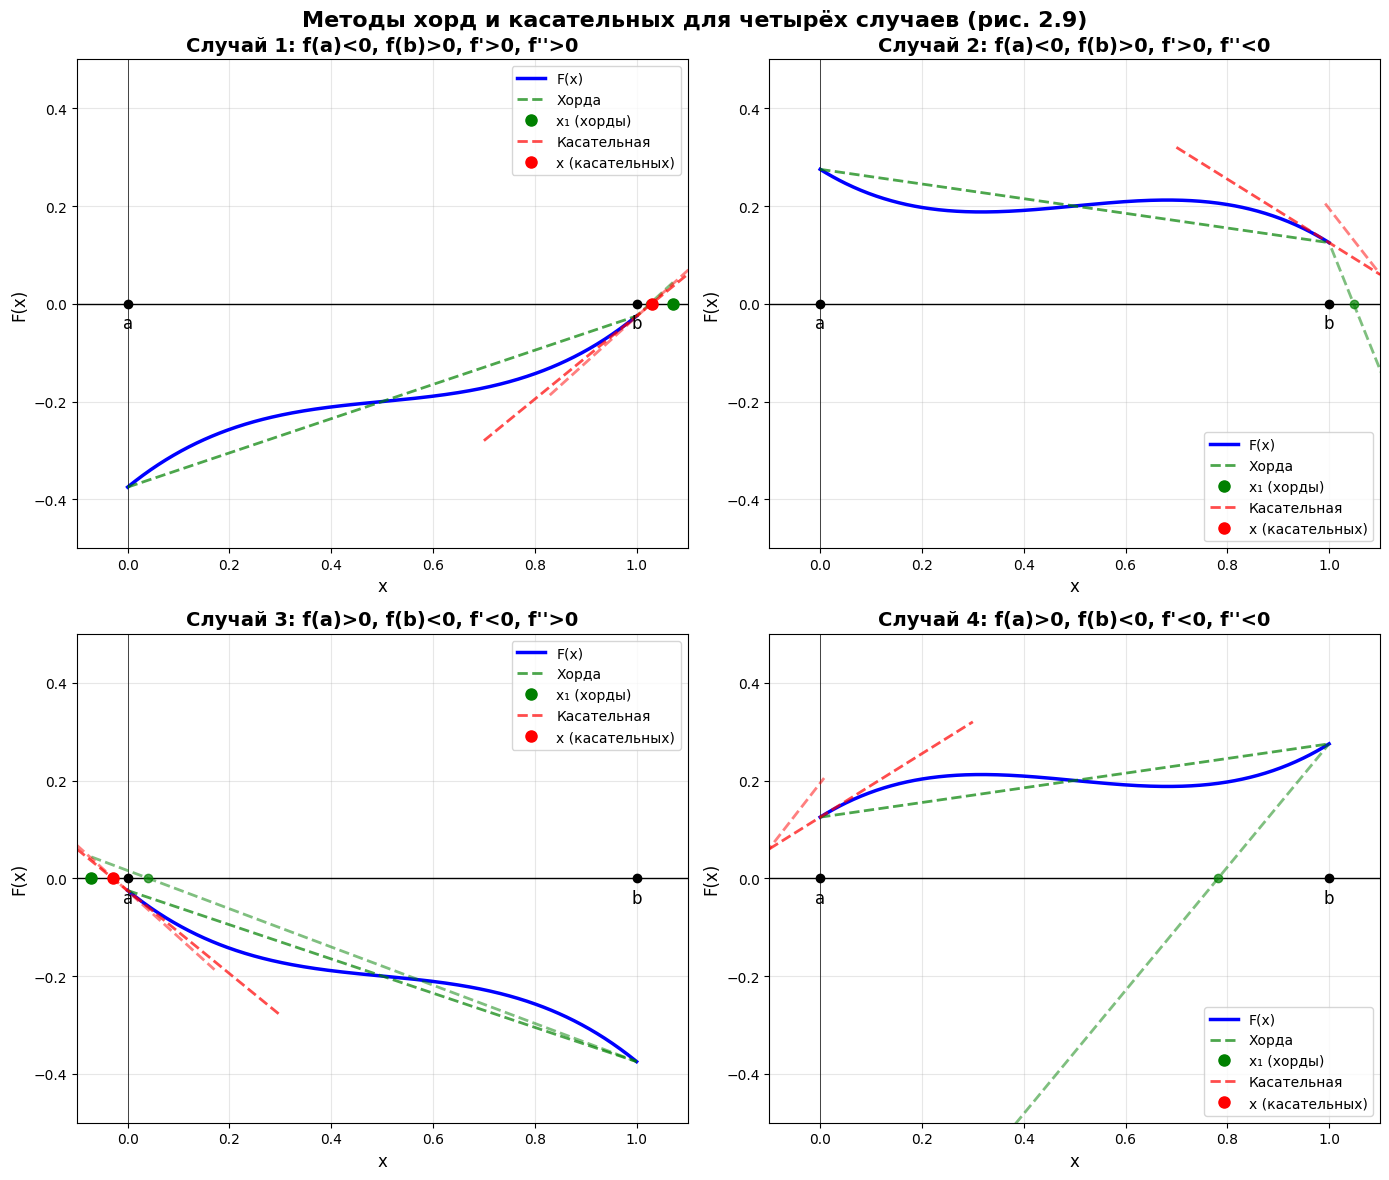

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Случай 1: f(a) < 0, f(b) > 0, f' > 0, f'' > 0
def case1(x):
    return (x - 0.5)**3 + 0.1*(x - 0.5) - 0.2

# Случай 2: f(a) < 0, f(b) > 0, f' > 0, f'' < 0
def case2(x):
    return -((x - 0.5)**3) + 0.1*(x - 0.5) + 0.2

# Случай 3: f(a) > 0, f(b) < 0, f' < 0, f'' > 0
def case3(x):
    return -((x - 0.5)**3) - 0.1*(x - 0.5) - 0.2

# Случай 4: f(a) > 0, f(b) < 0, f' < 0, f'' < 0
def case4(x):
    return (x - 0.5)**3 - 0.1*(x - 0.5) + 0.2

cases = [case1, case2, case3, case4]
titles = [
    "Случай 1: f(a)<0, f(b)>0, f'>0, f''>0",
    "Случай 2: f(a)<0, f(b)>0, f'>0, f''<0",
    "Случай 3: f(a)>0, f(b)<0, f'<0, f''>0",
    "Случай 4: f(a)>0, f(b)<0, f'<0, f''<0"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (func, title) in enumerate(zip(cases, titles)):
    ax = axes[i]
    x_vals = np.linspace(0, 1, 400)
    y_vals = func(x_vals)
    
    ax.plot(x_vals, y_vals, 'b-', linewidth=2.5, label='F(x)')
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=0.5)
    
    a, b = 0, 1
    ax.plot([a, b], [0, 0], 'ko', markersize=6)
    ax.text(a, -0.05, 'a', fontsize=12, ha='center')
    ax.text(b, -0.05, 'b', fontsize=12, ha='center')
    
    root_idx = np.where(np.diff(np.sign(y_vals)))[0]
    if len(root_idx) > 0:
        root_x = x_vals[root_idx[0]]
        root_y = func(root_x)
        ax.plot(root_x, root_y, 'k*', markersize=12, label='Корень ξ')

    x_chord1 = a - func(a) * (b - a) / (func(b) - func(a))
    y_chord1 = 0
    ax.plot([a, b], [func(a), func(b)], 'g--', linewidth=2, alpha=0.7, label='Хорда')
    ax.plot(x_chord1, y_chord1, 'go', markersize=8, label='x₁ (хорды)')
    
    x_chord2 = x_chord1 - func(x_chord1) * (b - x_chord1) / (func(b) - func(x_chord1))
    ax.plot([x_chord1, b], [func(x_chord1), func(b)], 'g--', linewidth=2, alpha=0.5)
    ax.plot(x_chord2, 0, 'go', markersize=6, alpha=0.7)
    
    h = 1e-5
    
    if i < 2:
        df_b = (func(b + h) - func(b - h)) / (2*h)
        x_tang1 = b - func(b) / df_b
        
        x_tan_line = np.linspace(b-0.3, b+0.1, 10)
        y_tan_line = func(b) + df_b * (x_tan_line - b)
        ax.plot(x_tan_line, y_tan_line, 'r--', linewidth=2, alpha=0.7, label='Касательная')
        ax.plot(x_tang1, 0, 'ro', markersize=8, label='x (касательных)')
        
        df_tang = (func(x_tang1 + h) - func(x_tang1 - h)) / (2*h)
        x_tang2 = x_tang1 - func(x_tang1) / df_tang
        x_tan_line2 = np.linspace(x_tang1-0.2, x_tang1+0.1, 10)
        y_tan_line2 = func(x_tang1) + df_tang * (x_tan_line2 - x_tang1)
        ax.plot(x_tan_line2, y_tan_line2, 'r--', linewidth=2, alpha=0.5)
        ax.plot(x_tang2, 0, 'ro', markersize=6, alpha=0.7)
    else:
        df_a = (func(a + h) - func(a - h)) / (2*h)
        x_tang1 = a - func(a) / df_a
        
        x_tan_line = np.linspace(a-0.1, a+0.3, 10)
        y_tan_line = func(a) + df_a * (x_tan_line - a)
        ax.plot(x_tan_line, y_tan_line, 'r--', linewidth=2, alpha=0.7, label='Касательная')
        ax.plot(x_tang1, 0, 'ro', markersize=8, label='x (касательных)')
        
        df_tang = (func(x_tang1 + h) - func(x_tang1 - h)) / (2*h)
        x_tang2 = x_tang1 - func(x_tang1) / df_tang
        x_tan_line2 = np.linspace(x_tang1-0.2, x_tang1+0.2, 10)
        y_tan_line2 = func(x_tang1) + df_tang * (x_tan_line2 - x_tang1)
        ax.plot(x_tan_line2, y_tan_line2, 'r--', linewidth=2, alpha=0.5)
        ax.plot(x_tang2, 0, 'ro', markersize=6, alpha=0.7)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('F(x)', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.5, 0.5)

plt.suptitle('Методы хорд и касательных для четырёх случаев (рис. 2.9)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Задание 2

In [26]:
import numpy as np

def f(x):
    """Исходная функция: x³ + 3x² - 24x + 1"""
    return x**3 + 3*x**2 - 24*x + 1

def df(x):
    """Первая производная: 3x² + 6x - 24"""
    return 3*x**2 + 6*x - 24

def d2f(x):
    """Вторая производная: 6x + 6"""
    return 6*x + 6

def combined_method(f, df, a, b, tol=1e-6, max_iter=100):
    print("--- Комбинированный метод хорд и касательных ---")
    print(f"Уравнение: x³ + 3x² - 24x + 1 = 0")
    print(f"Отрезок: [{a}, {b}]")
    print(f"Точность: {tol}\n")
    print("-" * 60)
    print(f"{'Итер.':^6} | {'Метод хорд':^15} | {'Метод касат.':^15} | {'|x_хорд - x_кас|':^18} | {'f(x_ср)':^15}")
    print("-" * 60)
    
    iterations = []
    
    for i in range(max_iter):
        x_chord = a - f(a) * (b - a) / (f(b) - f(a))
        
        if f(a) * d2f(a) > 0:
            x_newton = a - f(a) / df(a)
        else:
            x_newton = b - f(b) / df(b)
        
        iterations.append((x_chord, x_newton))
        
        x_mid = (x_chord + x_newton) / 2
        diff = abs(x_newton - x_chord)
        
        print(f"{i+1:6d} | {x_chord:15.8f} | {x_newton:15.8f} | {diff:18.10f} | {f(x_mid):15.2e}")
        
        if diff < tol:
            return x_mid, iterations
        
        if f(x_chord) * f(x_newton) < 0:
            a, b = x_chord, x_newton
        else:
            a, b = min(x_chord, x_newton), max(x_chord, x_newton)
    
    return (a + b) / 2, iterations

a, b = 0, 1
root, iterations = combined_method(f, df, a, b, tol=1e-6)

print(f"\nПриближённое значение корня: {root:.8f}")
print(f"Значение функции в корне: {f(root):.2e}")

--- Комбинированный метод хорд и касательных ---
Уравнение: x³ + 3x² - 24x + 1 = 0
Отрезок: [0, 1]
Точность: 1e-06

------------------------------------------------------------
Итер.  |   Метод хорд    |  Метод касат.   |  |x_хорд - x_кас|  |     f(x_ср)    
------------------------------------------------------------
     1 |      0.05000000 |      0.04166667 |       0.0083333333 |       -9.36e-02
     2 |      0.04188930 |      0.04188906 |       0.0000002448 |       -2.75e-06

Приближённое значение корня: 0.04188918
Значение функции в корне: -2.75e-06
